In [193]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import time
import pickle

from collections import Counter

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import (
    pad_sequences
)

from tensorflow.keras.models import (
    Model,
    load_model
)

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Bidirectional,
    Dense,
    Dropout,
    SpatialDropout1D,
    Concatenate
)

from tensorflow.keras.callbacks import (
    EarlyStopping
)

from tensorflow.keras.utils import (
    plot_model
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow Version:")

print(tf.__version__)

TensorFlow Version:
2.19.0


In [194]:
# RANDOM SEED

SEED = 42

np.random.seed(SEED)

tf.random.set_seed(SEED)

In [195]:
# LOAD DATASET

df = pd.read_csv(
    '/kaggle/input/datasets/taqtoqa/pubmed/final_cleaned_dataset.csv'
)

print(df.head())

                                       symptoms_text  age   gender   disease
0                  fever fatigue cough dyspnea edema   65     male  covid-19
1                  fever fatigue cough dyspnea edema   49  unknown  covid-19
2                       dyspnea edema erythema fever   66   female  covid-19
3               abdominal pain fever headache nausea   17   female  covid-19
4  arthralgia cough fatigue fever frequent falls ...   20   female  covid-19


In [196]:
# DATASET OVERVIEW

print(df.info())

print()

print("Dataset Shape:")

print(df.shape)

print()

print("Columns:")

print(df.columns)

print()

print("Missing Values:")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603 entries, 0 to 602
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   symptoms_text  603 non-null    object
 1   age            603 non-null    int64 
 2   gender         603 non-null    object
 3   disease        603 non-null    object
dtypes: int64(1), object(3)
memory usage: 19.0+ KB
None

Dataset Shape:
(603, 4)

Columns:
Index(['symptoms_text', 'age', 'gender', 'disease'], dtype='object')

Missing Values:
symptoms_text    0
age              0
gender           0
disease          0
dtype: int64


In [197]:
# CLEAN TEXT

df['symptoms_text'] = (
    df['symptoms_text']
    .astype(str)
    .str.lower()
    .str.strip()
)

disease
lung cancer     157
tuberculosis    153
covid-19        152
pneumonia       141
Name: count, dtype: int64


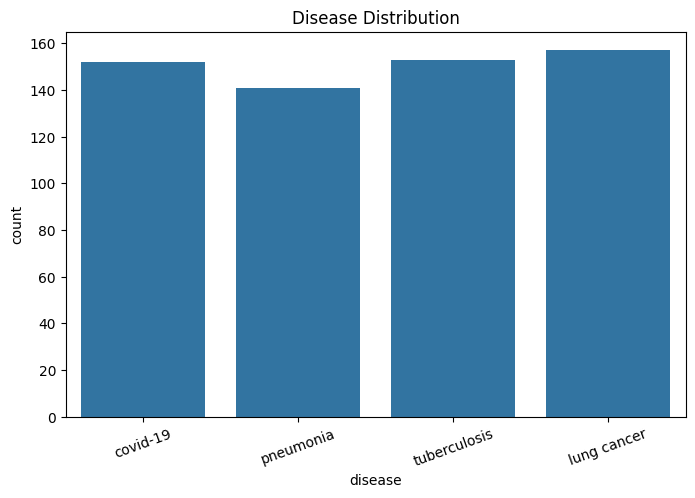

In [198]:
# DISEASE DISTRIBUTION

print(df['disease'].value_counts())

plt.figure(figsize=(8,5))

sns.countplot(
    x=df['disease']
)

plt.title("Disease Distribution")

plt.xticks(rotation=20)

plt.show()

gender
male       236
female     184
unknown    183
Name: count, dtype: int64


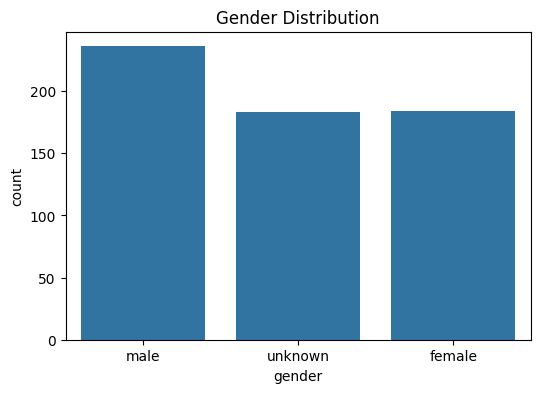

In [199]:
# GENDER DISTRIBUTION

print(df['gender'].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x=df['gender']
)

plt.title("Gender Distribution")

plt.show()

count    603.000000
mean       5.849088
std        3.722801
min        1.000000
25%        3.000000
50%        6.000000
75%        7.000000
max       29.000000
Name: text_length, dtype: float64


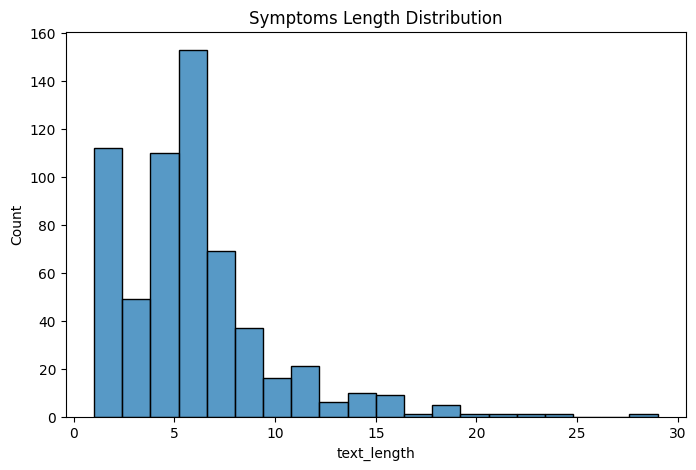

In [200]:
# TEXT LENGTH ANALYSIS

df['text_length'] = (
    df['symptoms_text']
    .apply(lambda x: len(x.split()))
)

print(df['text_length'].describe())

plt.figure(figsize=(8,5))

sns.histplot(
    df['text_length'],
    bins=20
)

plt.title(
    "Symptoms Length Distribution"
)

plt.show()

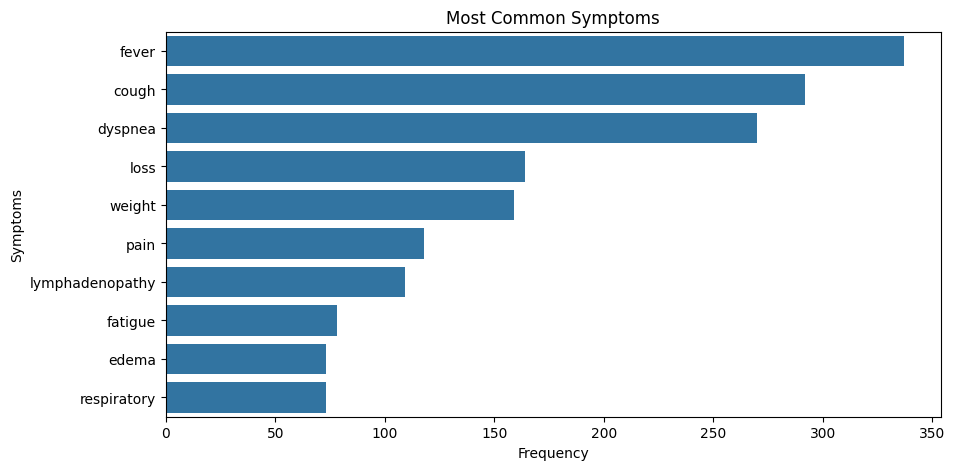

In [201]:
# MOST COMMON WORDS

all_words = ' '.join(
    df['symptoms_text']
).split()

common_words = Counter(
    all_words
).most_common(10)

words = [w[0] for w in common_words]

counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))

sns.barplot(
    x=counts,
    y=words
)

plt.title("Most Common Symptoms")

plt.xlabel("Frequency")

plt.ylabel("Symptoms")

plt.show()

In [202]:
# TOKENIZATION

MAX_WORDS = 3000
MAX_LEN = 40

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(df['symptoms_text'])

sequences = tokenizer.texts_to_sequences(df['symptoms_text'])

X_text = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

print(X_text.shape)


(603, 40)


In [203]:
# SAMPLE TOKENIZATION

print("Original Text:")

print(
    df['symptoms_text'].iloc[0]
)

print()

print("Sequence:")

print(sequences[0])

print()

print("Padded Sequence:")

print(X_text[0])

Original Text:
fever fatigue cough dyspnea edema

Sequence:
[2, 9, 3, 4, 10]

Padded Sequence:
[ 2  9  3  4 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


In [204]:
# =========================================
# ENCODE LABELS
# =========================================

disease_encoder = LabelEncoder()

df['disease_label'] = (
    disease_encoder.fit_transform(
        df['disease']
    )
)

y = np.array(
    df['disease_label'],
    dtype=np.int32
)

print("y shape:")

print(y.shape)

print()

print("Classes:")

print(disease_encoder.classes_)

y shape:
(603,)

Classes:
['covid-19' 'lung cancer' 'pneumonia' 'tuberculosis']


In [205]:
# META FEATURES

from sklearn.preprocessing import LabelEncoder
import numpy as np

gender_encoder = LabelEncoder()

df['gender_encoded'] = gender_encoder.fit_transform(df['gender'])

X_meta = np.array(
    df[['age', 'gender_encoded']],
    dtype=np.float32
)

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df['disease'])

y = np.array(y, dtype=np.int32)

print(X_meta.shape)
print(y.shape)

(603, 2)
(603,)


In [206]:
# FINAL DATA CHECK

print("X_text shape:")

print(X_text.shape)

print()

print("X_meta shape:")

print(X_meta.shape)

print()

print("y shape:")

print(y.shape)

X_text shape:
(603, 40)

X_meta shape:
(603, 2)

y shape:
(603,)


In [207]:
# TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

(
    X_text_train,
    X_text_test,
    X_meta_train,
    X_meta_test,
    y_train,
    y_test
) = train_test_split(
    X_text,
    X_meta,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [208]:
# TEXT INPUT BRANCH

text_input = Input(
    shape=(MAX_LEN,)
)

embedding = Embedding(
    input_dim=MAX_WORDS,
    output_dim=32
)(text_input)

embedding = SpatialDropout1D(
    0.3
)(embedding)

lstm = Bidirectional(
    LSTM(
        32,
        dropout=0.3
    )
)(embedding)

In [209]:
# META INPUT BRANCH

meta_input = Input(
    shape=(2,)
)

meta_dense = Dense(
    32,
    activation='relu'
)(meta_input)

meta_dense = Dropout(
    0.2
)(meta_dense)

In [210]:
# CONCATENATE LAYERS

combined = Concatenate()(
    [lstm, meta_dense]
)

dense = Dense(
    128,
    activation='relu'
)(combined)

dense = Dropout(
    0.4
)(dense)

dense = Dense(
    64,
    activation='relu'
)(dense)

output = Dense(
    4,
    activation='softmax'
)(dense)

In [211]:
# BUILD PROFESSIONAL MODEL

import tensorflow as tf

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    BatchNormalization,
    Concatenate
)

# TEXT INPUT
text_input = Input(shape=(MAX_LEN,))

embedding = Embedding(
    input_dim=MAX_WORDS,
    output_dim=128
)(text_input)

embedding = SpatialDropout1D(0.3)(embedding)

lstm = Bidirectional(
    LSTM(
        128,
        dropout=0.3,
        recurrent_dropout=0.3
    )
)(embedding)

# META INPUT
meta_input = Input(shape=(2,))

meta_dense = Dense(
    32,
    activation='relu'
)(meta_input)

meta_dense = BatchNormalization()(meta_dense)

# MERGE
merged = Concatenate()([lstm, meta_dense])

dense = Dense(
    128,
    activation='relu'
)(merged)

dense = Dropout(0.4)(dense)

dense = BatchNormalization()(dense)

dense = Dense(
    64,
    activation='relu'
)(dense)

dense = Dropout(0.3)(dense)

output = Dense(
    4,
    activation='softmax'
)(dense)

# FINAL MODEL
model = Model(
    inputs=[text_input, meta_input],
    outputs=output
)

# COMPILE
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 40)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 40, 128)   │    384,000 │ input_layer_13[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d_8 │ (None, 40, 128)   │          0 │ embedding_8[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 32)        │         96 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_11    │ (None, 256)       │    263,168 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_29[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 288)       │          0 │ bidirectional_11… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 128)       │     36,992 │ concatenate_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 128)       │          0 │ dense_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dropout_16[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 64)        │          0 │ dense_31[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 4)         │        260 │ dropout_17[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 693,412 (2.65 MB)

 Trainable params: 693,092 (2.64 MB)

 Non-trainable params: 320 (1.25 KB)

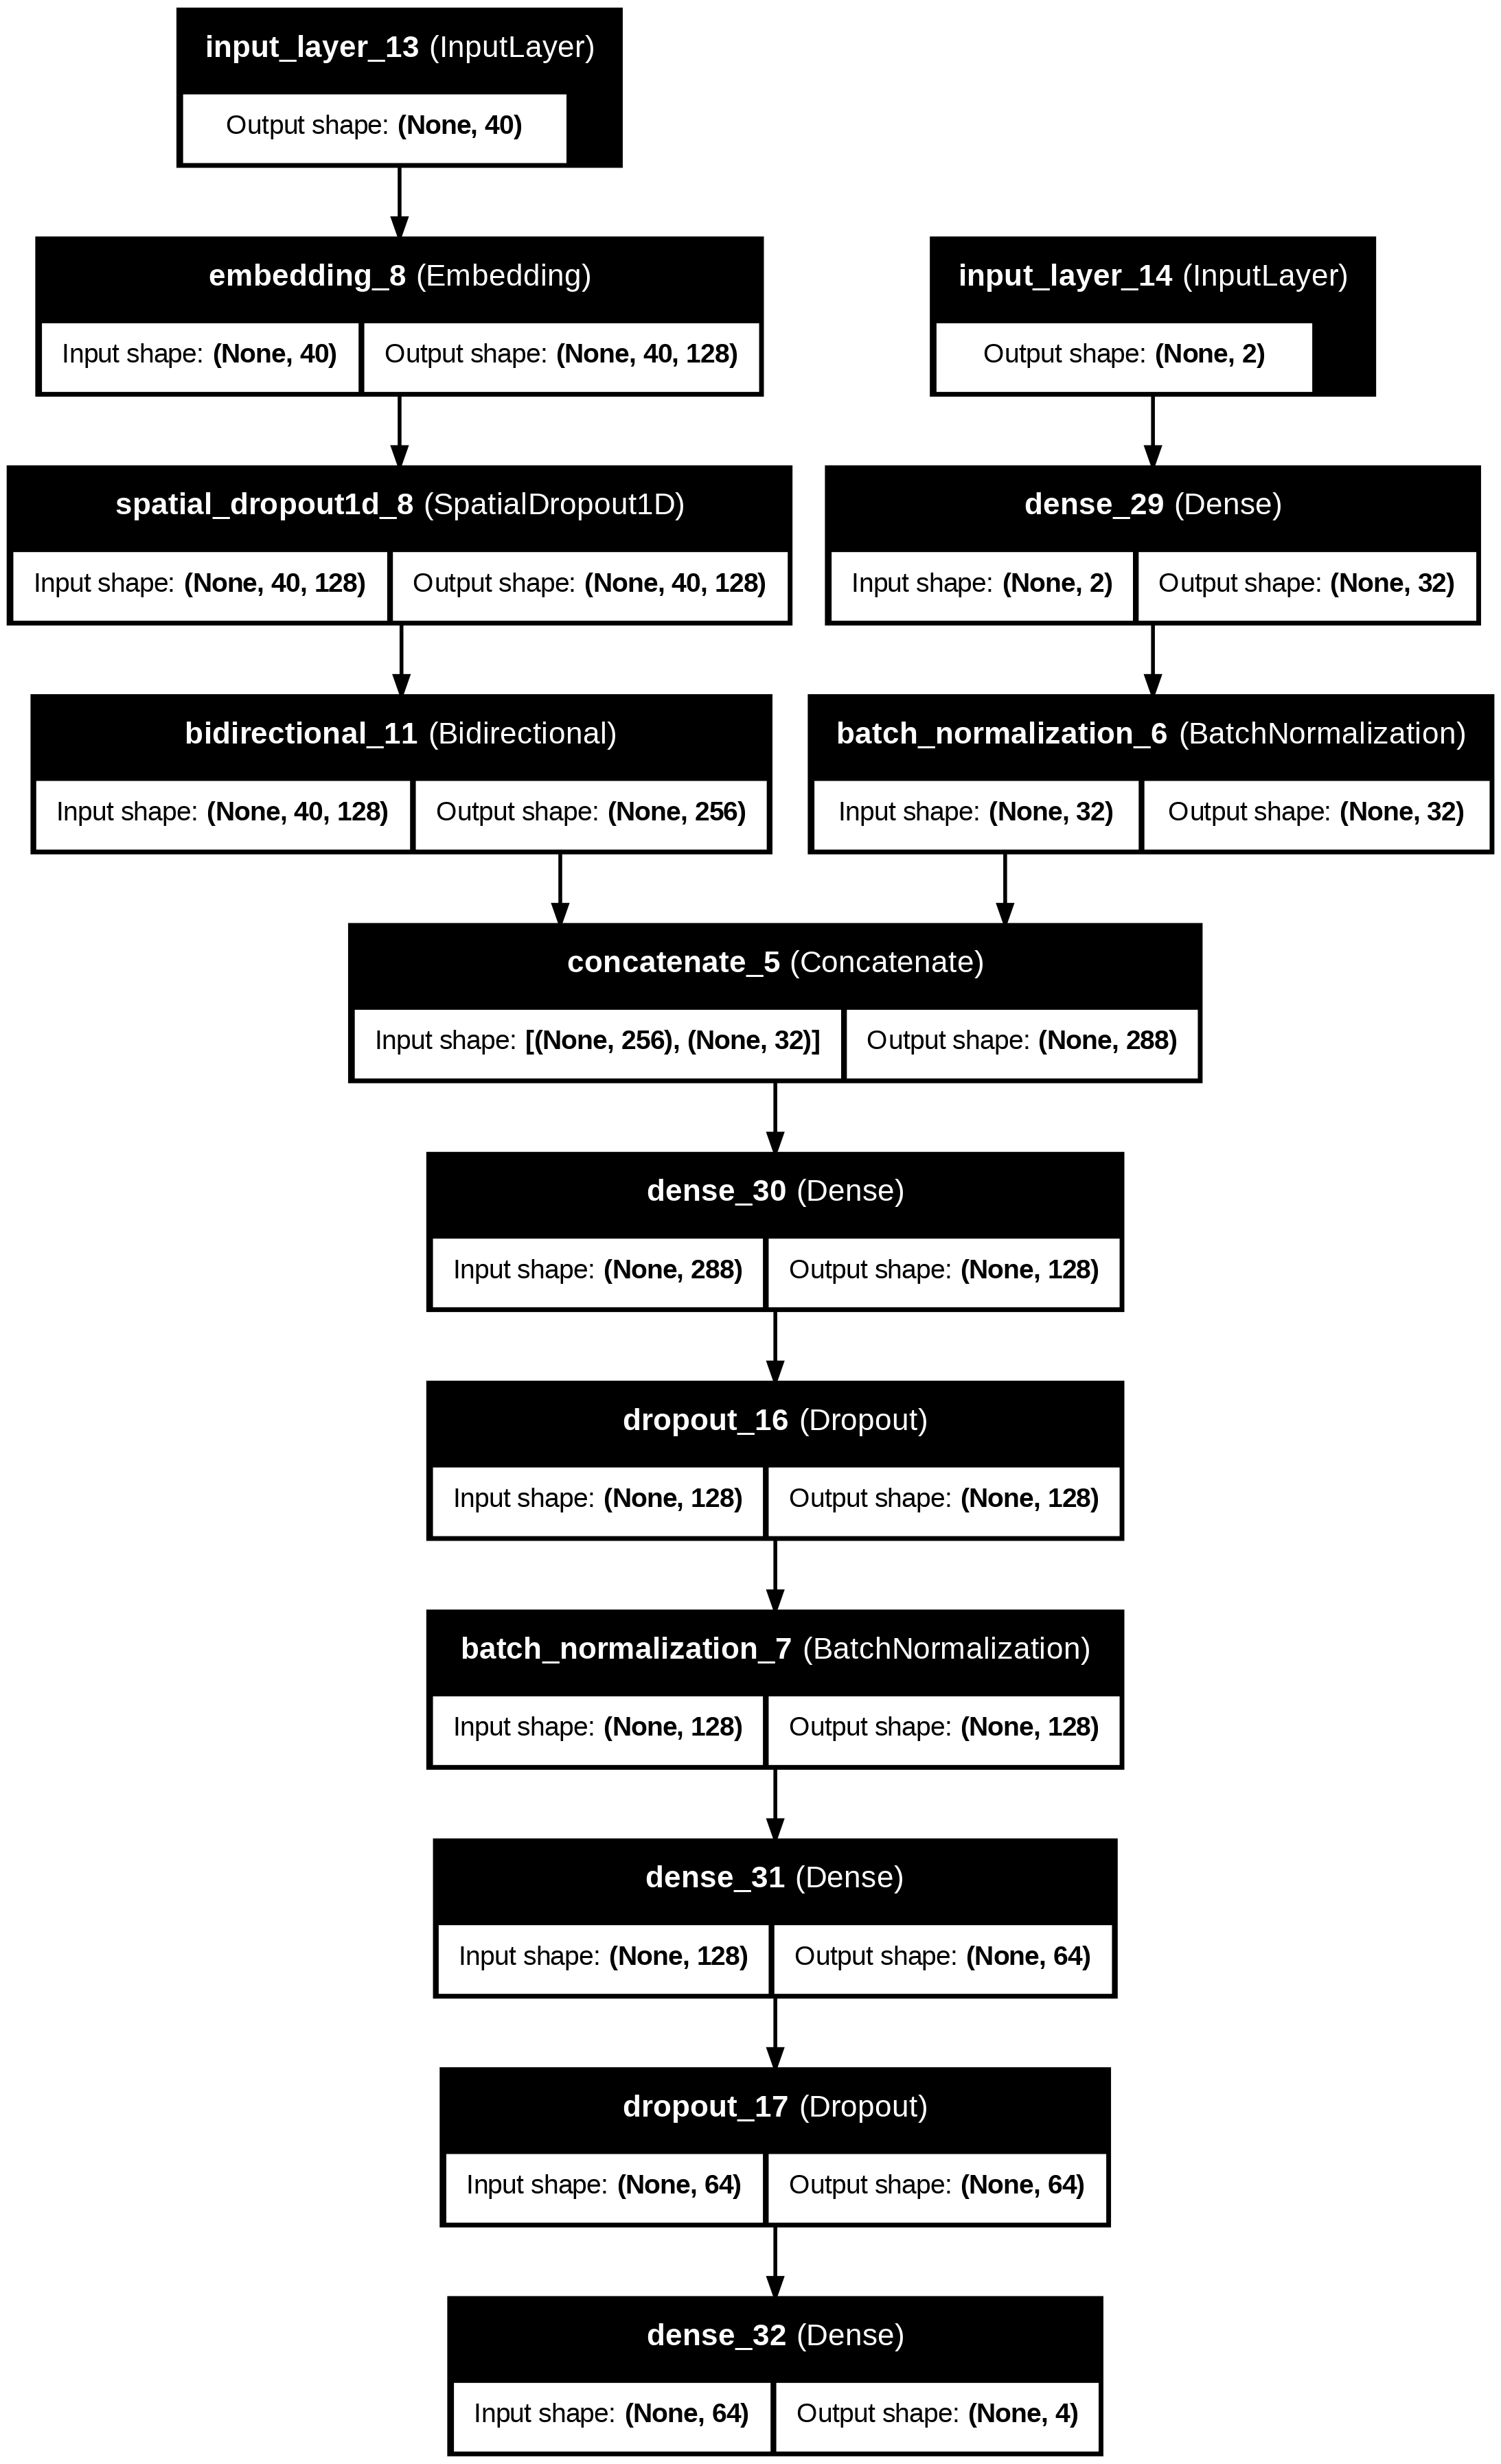

In [212]:
# MODEL ARCHITECTURE VISUALIZATION

plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

In [213]:
# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [214]:
# TRAIN MODEL

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

history = model.fit(
    [X_text_train, X_meta_train],
    y_train,

    validation_data=(
        [X_text_test, X_meta_test],
        y_test
    ),

    epochs=40,
    batch_size=16,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 215ms/step - accuracy: 0.2119 - loss: 1.7118 - val_accuracy: 0.2397 - val_loss: 1.4795 - learning_rate: 5.0000e-04
Epoch 2/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 184ms/step - accuracy: 0.2732 - loss: 1.6045 - val_accuracy: 0.2149 - val_loss: 1.4077 - learning_rate: 5.0000e-04
Epoch 3/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 183ms/step - accuracy: 0.2617 - loss: 1.5669 - val_accuracy: 0.2149 - val_loss: 1.4043 - learning_rate: 5.0000e-04
Epoch 4/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.2795 - loss: 1.5337 - val_accuracy: 0.1901 - val_loss: 1.3984 - learning_rate: 5.0000e-04
Epoch 5/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.3299 - loss: 1.5189 - val_accuracy: 0.3223 - val_loss: 1.3618 - learning_rate: 5.0000e-04
Epoch 6/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 186ms/step - accuracy: 0.3663 - loss: 1.3979 - val_accuracy: 0.3388 - val_loss: 1.3439 - learning_rate: 5.0000e-04
Epoch 7/40
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - accuracy:

In [215]:
# BEST VALIDATION ACCURACY

best_accuracy = max(
    history.history['val_accuracy']
)

print(
    "Best Validation Accuracy:"
)

print(
    round(
        best_accuracy * 100,
        2
    ),
    "%"
)

Best Validation Accuracy:
57.85 %


In [216]:
# EVALUATE MODEL

predictions = model.predict(
    [X_text_test, X_meta_test]
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    predicted_classes
)

print("Accuracy:")

print(accuracy)

print()

print(
    classification_report(
        y_test,
        predicted_classes
    )
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step
Accuracy:
0.5785123966942148

              precision    recall  f1-score   support

           0       0.58      0.63      0.60        30
           1       0.57      0.72      0.64        32
           2       0.55      0.43      0.48        28
           3       0.62      0.52      0.56        31

    accuracy                           0.58       121
   macro avg       0.58      0.57      0.57       121
weighted avg       0.58      0.58      0.57       121



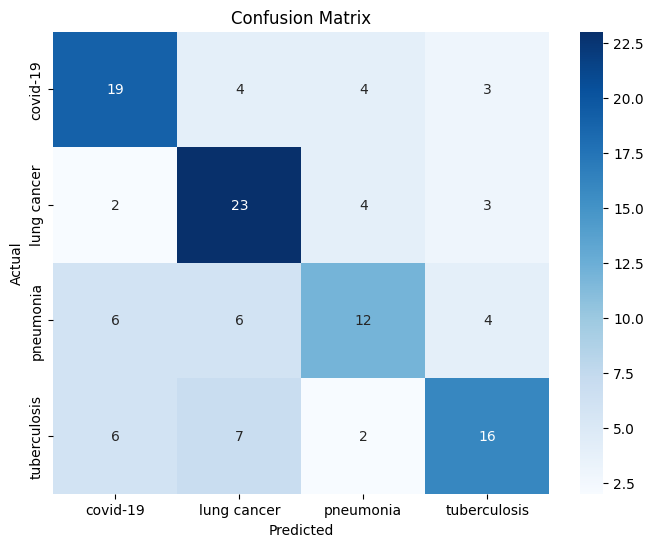

In [217]:
# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    predicted_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=disease_encoder.classes_,
    yticklabels=disease_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

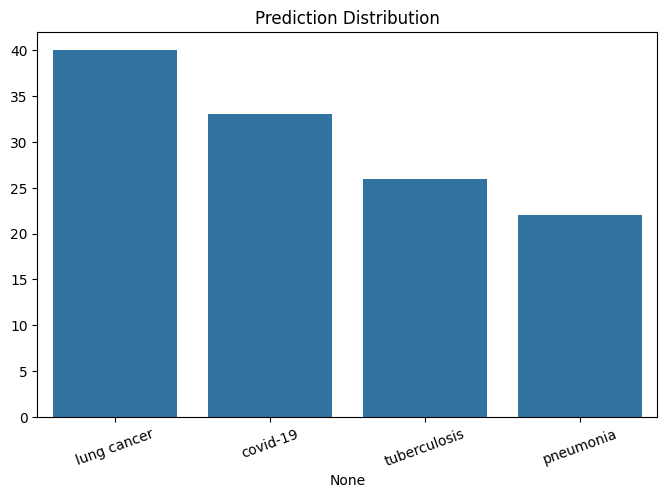

In [218]:
# PREDICTION DISTRIBUTION

predicted_labels = (
    disease_encoder
    .inverse_transform(
        predicted_classes
    )
)

prediction_counts = pd.Series(
    predicted_labels
).value_counts()

plt.figure(figsize=(8,5))

sns.barplot(
    x=prediction_counts.index,
    y=prediction_counts.values
)

plt.title(
    "Prediction Distribution"
)

plt.xticks(rotation=20)

plt.show()

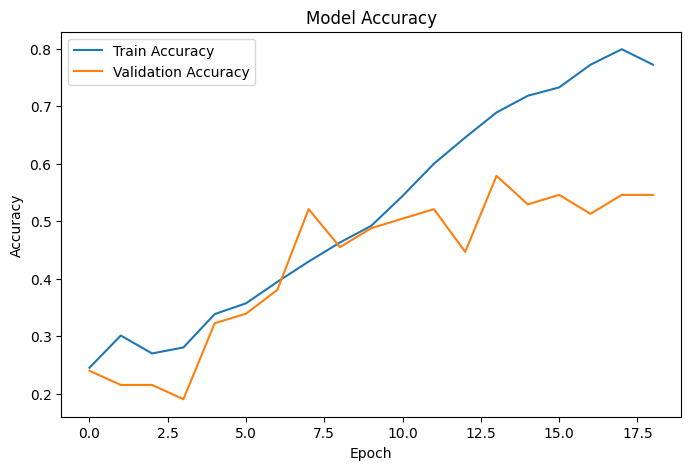

In [219]:
# ACCURACY PLOT

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

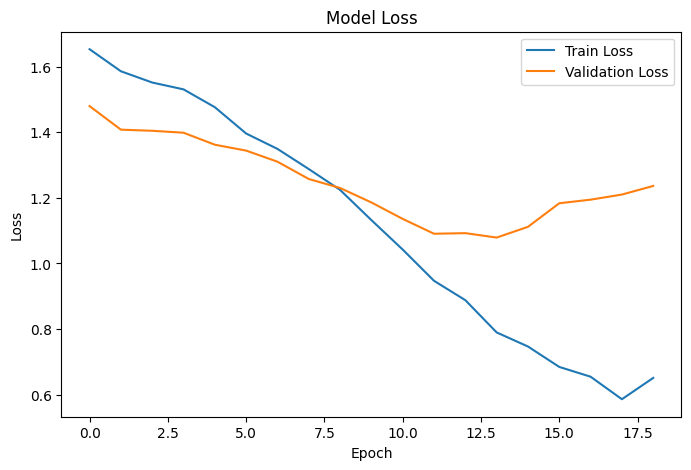

In [220]:
# LOSS PLOT

plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [221]:
# OVERFITTING CHECK

train_acc = max(
    history.history['accuracy']
)

val_acc = max(
    history.history['val_accuracy']
)

gap = train_acc - val_acc

print("Train Accuracy:")

print(
    round(train_acc * 100, 2),
    "%"
)

print()

print("Validation Accuracy:")

print(
    round(val_acc * 100, 2),
    "%"
)

print()

print("Generalization Gap:")

print(
    round(gap * 100, 2),
    "%"
)

Train Accuracy:
79.88 %

Validation Accuracy:
57.85 %

Generalization Gap:
22.02 %


In [222]:
# SAVE TOKENIZER & ENCODERS

with open(
    'tokenizer.pkl',
    'wb'
) as f:

    pickle.dump(
        tokenizer,
        f
    )

with open(
    'gender_encoder.pkl',
    'wb'
) as f:

    pickle.dump(
        gender_encoder,
        f
    )

with open(
    'disease_encoder.pkl',
    'wb'
) as f:

    pickle.dump(
        disease_encoder,
        f
    )

print(
    "Tokenizer & Encoders Saved"
)

Tokenizer & Encoders Saved


In [223]:
# SAVE MODEL

model.save(
    "disease_prediction_model.keras"
)

print(
    "Model Saved Successfully"
)

Model Saved Successfully


In [224]:
# LOAD MODEL TEST

loaded_model = load_model(
    "disease_prediction_model.keras"
)

print(
    "Model Loaded Successfully"
)

Model Loaded Successfully


In [232]:
# PREDICTION FUNCTION

def predict_disease(
    symptoms,
    age,
    gender
):

    seq = tokenizer.texts_to_sequences(
        [symptoms.lower()]
    )

    padded = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post'
    )

    gender_encoded = (
        gender_encoder.transform(
            [gender]
        )[0]
    )

    meta = np.array(
        [[age, gender_encoded]],
        dtype=np.float32
    )

    pred = model.predict(
        [padded, meta],
        verbose=0
    )

    predicted_class = np.argmax(
        pred
    )

    disease = (
        disease_encoder
        .inverse_transform(
            [predicted_class]
        )[0]
    )

    confidence = np.max(pred)

    return disease, confidence

In [235]:
# PREDICT NEW PATIENT

def predict_disease(symptoms, age, gender):

    gender_value = gender_encoder.transform([gender])[0]

    
    sequence = tokenizer.texts_to_sequences([symptoms])

    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )


    meta_data = np.array(
        [[age, gender_value]],
        dtype=np.float32
    )


    prediction = model.predict(
        [padded_sequence, meta_data],
        verbose=0
    )

    # Highest probability
    predicted_class = np.argmax(prediction)

    disease_name = label_encoder.inverse_transform(
        [predicted_class]
    )[0]

    confidence = np.max(prediction) * 100

    # Print probabilities
    print("=================================")
    print("Predicted Disease:")
    print(disease_name)

    print()

    print("Confidence:")
    print(f"{confidence:.2f}%")

    print()

    print("All Probabilities:")
    print("---------------------------------")

    for i, prob in enumerate(prediction[0]):

        disease = label_encoder.inverse_transform([i])[0]

        print(
            f"{disease}: {prob * 100:.2f}%"
        )

    print("=================================")

In [236]:
# TEST PREDICTION

predict_disease(
    symptoms="fever cough chest pain fatigue",
    age=45,
    gender="male"
)

Predicted Disease:
covid-19

Confidence:
65.68%

All Probabilities:
---------------------------------
covid-19: 65.68%
lung cancer: 4.44%
pneumonia: 16.29%
tuberculosis: 13.59%
